# Exercise 4.A Introduction to Linear Regression

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

## Lab 1
### Running a sample script

In [2]:
# Sample dataset: hours studied vs. exam score
data = {
    'hours_studied': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'exam_score':    [52, 55, 60, 65, 68, 72, 75, 80, 85, 90]
}
df = pd.DataFrame(data)

# Step 1: Define features (X) and target (y)
X = df[['hours_studied']]   # 2D: double brackets give a DataFrame, not a Series
y = df['exam_score']        # 1D: single brackets give a Series

# Step 2: Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 3: Create the model and fit it to training data
model = LinearRegression()
model.fit(X_train, y_train)

print('Model trained successfully.')

Model trained successfully.


### Working through the sample script

In [3]:
print(f'\nSlope (coefficient): {model.coef_[0]:.2f}')
print(f'Intercept: {model.intercept_:.2f}')


Slope (coefficient): 4.10
Intercept: 47.68


In [4]:
y_pred = model.predict(X_test)
print('Actual scores: ', list(y_test))
print('Predicted scores:', list(y_pred.round(1)))

Actual scores:  [85, 55]
Predicted scores: [np.float64(84.6), np.float64(55.9)]


In [5]:
r_squared = model.score(X_test, y_test)
print(f'R² score: {r_squared:.3f}')

R² score: 0.998


R² tells us how much of the variation in exam scores is explained by the model.
Closer to 1.0 = strong fit. Closer to 0 = the model is barely better than predicting the mean every time.


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


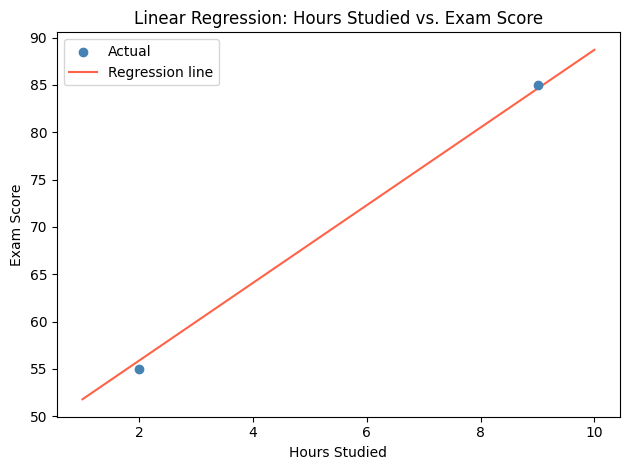

In [7]:
plt.scatter(X_test, y_test, color='steelblue', label='Actual', zorder=3)

x_range = np.linspace(
    X['hours_studied'].min(),
    X['hours_studied'].max(),
    100).reshape(-1, 1)
y_line = model.predict(x_range)

plt.plot(x_range, y_line, color='tomato', label='Regression line')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Linear Regression: Hours Studied vs. Exam Score')
plt.legend()
plt.tight_layout()
plt.show()

## Lab 2
### Building your own model

In [8]:
ad_data = {
    'monthly_ad_spend': [500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500,
                         5000, 5500, 6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000],
    'monthly_revenue': [4200, 5100, 6800, 7400, 8900, 9200, 10500, 11800, 12400,
                        13100, 14200, 15600, 15900, 17200, 18100, 19400, 20200, 21500, 22100, 23800]
}
df_ads = pd.DataFrame(ad_data)
df_ads

,monthly_ad_spend,monthly_revenue
0,500,4200
1,1000,5100
2,1500,6800
3,2000,7400
4,2500,8900
5,3000,9200
6,3500,10500
7,4000,11800
8,4500,12400
9,5000,13100


In [11]:
X2 = df_ads[['monthly_ad_spend']]
y2 = df_ads['monthly_revenue']
print(f"X2 shape: {X2.shape}")
print(f"y2 shape: {y2.shape}")

X2 shape: (20, 1)
y2 shape: (20,)


In [12]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42)

In [14]:
model2 = LinearRegression()
model2.fit(X2_train, y2_train)
print("Model trained successfully.")

Model trained successfully.


In [16]:
print(f"Slope: {model2.coef_[0]:.2f}")
print(f"Intercept: {model2.intercept_:.2f}")

Slope: 1.96
Intercept: 3625.89


### Making predictions and evaluating the model

In [17]:
y2_pred = model2.predict(X2_test)
print("Actual revenue: ", list(y2_test))
print("Predicted revenue:", list(y2_pred.round(2)))

Actual revenue:  [4200, 21500, 19400, 5100]
Predicted revenue: [np.float64(4603.85), np.float64(21229.03), np.float64(19273.13), np.float64(5581.8)]


In [18]:
r2_squared = model2.score(X2_test, y2_test)
print(f"R² score: {r2_squared:.3f}")

R² score: 0.998


### Visualizing the results

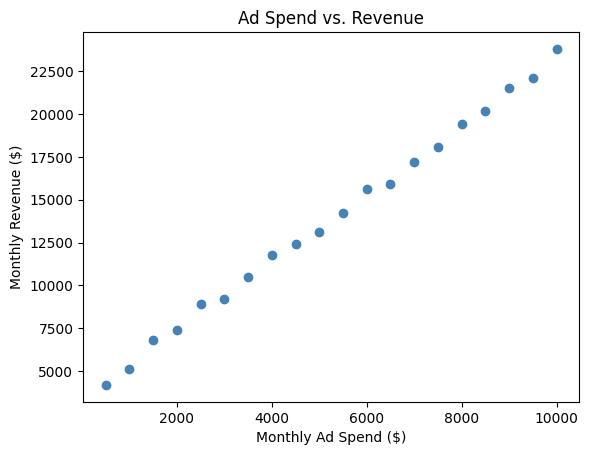

In [19]:
plt.scatter(X2, y2, color='steelblue', label='Actual')
plt.xlabel('Monthly Ad Spend ($)')
plt.ylabel('Monthly Revenue ($)')
plt.title('Ad Spend vs. Revenue')
plt.show()

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


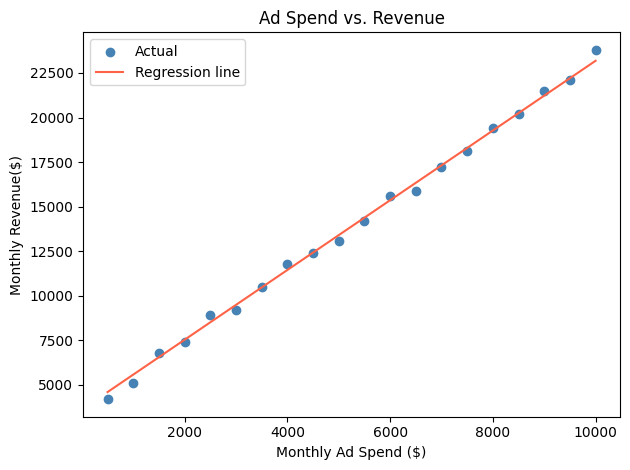

In [20]:
plt.scatter(X2, y2, color='steelblue', label='Actual')

x2_range = np.linspace(
    X2['monthly_ad_spend'].min(),
    X2['monthly_ad_spend'].max(),
    100).reshape(-1, 1)
y2_line = model2.predict(x2_range)

plt.plot(x2_range, y2_line, color='tomato', label='Regression line')
plt.xlabel('Monthly Ad Spend ($)')
plt.ylabel('Monthly Revenue($)')
plt.title('Ad Spend vs. Revenue')
plt.legend()
plt.tight_layout()
plt.show()